# Evaluación Parcial N°1 - Fundamentos de Deep Learning
## Clasificación de Personajes de Los Simpsons con MLP

**Asignatura:** Deep Learning
**Estudiante:** Álvaro Flores
**Sede:** Duoc UC Puerto Montt
**Fecha:** 20/04/2026

**Objetivo:** Implementar una red neuronal artificial multicapa (MLP) para clasificar imágenes de 18 personajes de Los Simpsons, aplicando los fundamentos de Deep Learning vistos durante la asignatura.

## 1. Introducción

### Descripción del problema
El dataset consiste en imágenes con personajes caracteristicos de "Los Simpsons" con un total de  18 personajes principales. Cada imagen puede contener al personaje en diferentes poses, posiciones o incluso con otros personajes de fondo.

### Desafíos del problema
- Las imágenes tienen diferentes tamaños originales
- Los personajes aparecen en múltiples poses y ángulos
- Algunas clases tienen pocas imágenes (ej: nelson_muntz tiene solo 358)
- El fondo puede contener otros personajes (ruido visual)

### Enfoque de solución
Se implementará una red MLP (Multilayer Perceptron) porque la rúbrica específicamente pide este tipo de arquitectura, no CNN. Se probarán diferentes configuraciones para encontrar la óptima.

In [1]:
# ============================================
# Importar librerías necesarias
# ============================================
from google.colab.patches import cv2_imshow
import cv2
import os
import numpy as np
import keras
import glob
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Librerías importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✅ Librerías importadas correctamente
TensorFlow version: 2.19.0


In [2]:
# ============================================
# Montar Google Drive y copiar los datos
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import tarfile
import os

os.makedirs("/root/.keras/datasets/", exist_ok=True)

# Copiar archivos desde Drive
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_train.tar.gz" "/root/.keras/datasets/simpsons_train.tar.gz"
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_test.tar.gz" "/root/.keras/datasets/simpsons_test.tar.gz"

# Descomprimir
!tar -xzf "/root/.keras/datasets/simpsons_train.tar.gz" -C "/root/.keras/datasets/"
!tar -xzf "/root/.keras/datasets/simpsons_test.tar.gz" -C "/root/.keras/datasets/"

print("✅ Datos copiados y descomprimidos")

Mounted at /content/drive
✅ Datos copiados y descomprimidos


In [3]:
# ============================================
# Verificar que los datos se cargaron correctamente
# ============================================
print("Carpetas de entrenamiento (personajes):")
!ls /root/.keras/datasets/simpsons/ | head -10

print("\nPrimeras imágenes de prueba:")
!ls /root/.keras/datasets/simpsons_testset/ | head -10

Carpetas de entrenamiento (personajes):
abraham_grampa_simpson
agnes_skinner
apu_nahasapeemapetilon
barney_gumble
bart_simpson
bumblebee_man
carl_carlson
charles_montgomery_burns
chief_wiggum
cletus_spuckler

Primeras imágenes de prueba:
abraham_grampa_simpson_0.jpg
abraham_grampa_simpson_10.jpg
abraham_grampa_simpson_11.jpg
abraham_grampa_simpson_12.jpg
abraham_grampa_simpson_13.jpg
abraham_grampa_simpson_14.jpg
abraham_grampa_simpson_15.jpg
abraham_grampa_simpson_16.jpg
abraham_grampa_simpson_17.jpg
abraham_grampa_simpson_18.jpg


### Análisis del dataset

Cada personaje tiene su propia carpeta con imágenes .jpg
los nombres de las carpetas indican el personaje (ej: 'homer_simpson').
El conjunto de prueba tiene imágenes sueltas con nombres como 'homer_simpson_0.jpg'

**Desbalance de clases:**
- La clase con más imágenes: homer_simpson (2246)
- La clase con menos imágenes: nelson_muntz (358)
- Esto afectará el rendimiento: clases con pocas imágenes serán más difíciles de clasificar

In [4]:
# ============================================
# Definir mapeo de personajes y funciones de carga
# ============================================
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

IMG_SIZE = 64

def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

print("✅ Funciones definidas")

✅ Funciones definidas


**¿Por qué 64x64 y no otro tamaño?**
- 32x32: perderíamos detalles importantes (ojos, boca, rasgos)
- 128x128: más memoria y tiempo de entrenamiento (12288 vs 49152 parámetros de entrada)
- 64x64: balance óptimo entre calidad y eficiencia computacional

**Cálculo del tamaño de entrada:**
64 x 64 x 3 (canales RGB) = 12,288 neuronas en la capa de entrada

In [5]:
# ============================================
# Ejecutar la carga de datos
# ============================================
DATASET_TRAIN_PATH = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

# Barajar
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar
X = X / 255.0
X_t = X_t / 255.0

print(f"\n✅ Shape entrenamiento: {X.shape}")
print(f"✅ Shape prueba: {X_t.shape}")

Leyendo 913 imágenes de abraham_grampa_simpson
Leyendo 623 imágenes de apu_nahasapeemapetilon
Leyendo 1342 imágenes de bart_simpson
Leyendo 1193 imágenes de charles_montgomery_burns
Leyendo 986 imágenes de chief_wiggum
Leyendo 469 imágenes de comic_book_guy
Leyendo 457 imágenes de edna_krabappel
Leyendo 2246 imágenes de homer_simpson
Leyendo 498 imágenes de kent_brockman
Leyendo 1206 imágenes de krusty_the_clown
Leyendo 1354 imágenes de lisa_simpson
Leyendo 1291 imágenes de marge_simpson
Leyendo 1079 imágenes de milhouse_van_houten
Leyendo 1452 imágenes de moe_szyslak
Leyendo 1454 imágenes de ned_flanders
Leyendo 358 imágenes de nelson_muntz
Leyendo 1194 imágenes de principal_skinner
Leyendo 877 imágenes de sideshow_bob
Leídas 890 imágenes de test

✅ Shape entrenamiento: (18992, 64, 64, 3)
✅ Shape prueba: (890, 64, 64, 3)


**¿Por qué dividir por 255?**
- Los píxeles originales van de 0 a 255
- Valores grandes pueden causar explosión del gradiente
- Al normalizar a [0,1], los gradientes se mantienen en rangos estables

**¿Por qué barajar?**
- Las imágenes se leen personaje por personaje
- Sin barajar, la validación tomaría solo los últimos personajes
- El barajado asegura que train y validación tengan mezcla de todas las clases


In [6]:
# ============================================
# Dividir datos en entrenamiento y validación (80/20)
# ============================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


**¿Por qué 80/20?**
- Suficientes datos para entrenar (15,193 imágenes)
- Suficientes datos para validar (3,799 imágenes)
- Proporción estándar en deep learning

**¿Por qué stratify?**
- Mantiene el mismo porcentaje de cada personaje en train y val
- Evita que una clase desbalanceada desaparezca de validación

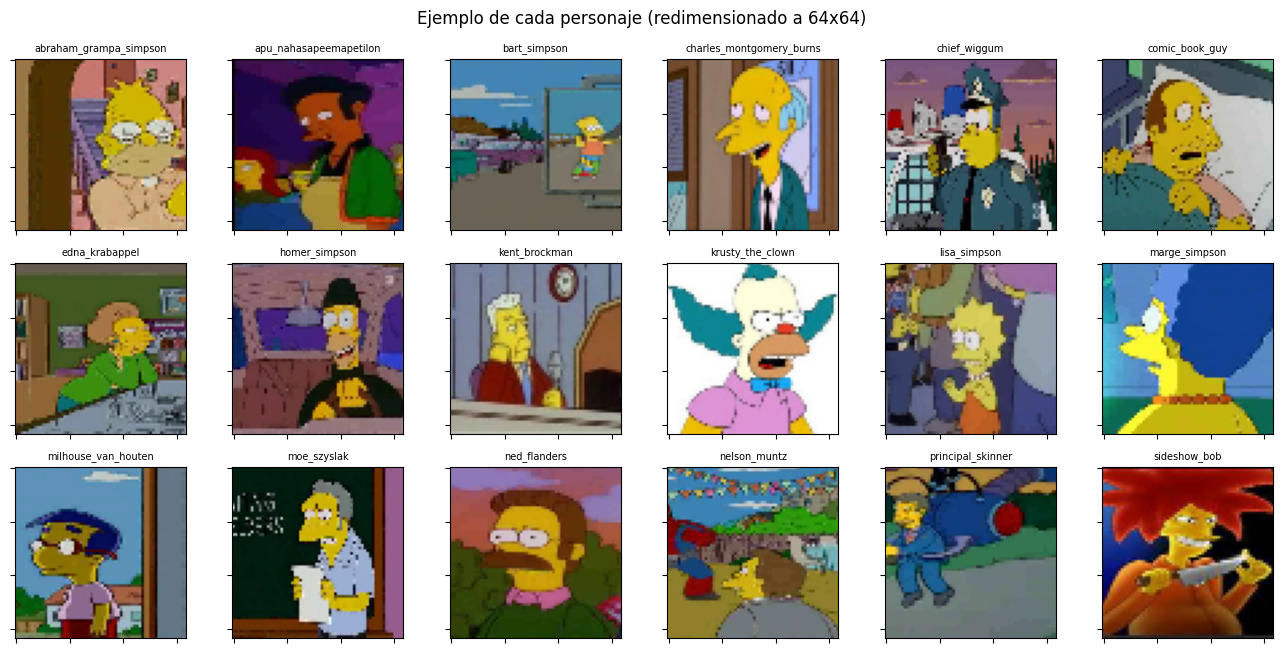

In [17]:
# ============================================
# Mostrar una imagen de ejemplo por cada personaje
# ============================================
nombres = list(MAP_CHARACTERS.values())

h = 3  # filas
w = 6  # columnas (3x6 = 18 personajes)

fig, axs = plt.subplots(h, w, figsize=(2.2*w, 2.2*h))

for i in range(h):
    for j in range(w):
        idx_personaje = i * w + j
        if idx_personaje < len(nombres):
            personaje = nombres[idx_personaje]

            # Obtener una imagen aleatoria de ese personaje
            ruta_personaje = os.path.join(DATASET_TRAIN_PATH, personaje)
            imagenes = [f for f in os.listdir(ruta_personaje) if f.endswith('jpg')]
            imagen_aleatoria = np.random.choice(imagenes)

            # Cargar y mostrar
            img = cv2.imread(os.path.join(ruta_personaje, imagen_aleatoria))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axs[i, j].set_title(personaje, fontsize=7)
            axs[i, j].grid(False)
            axs[i, j].set_xticklabels([])
            axs[i, j].set_yticklabels([])
            axs[i, j].imshow(img)
        else:
            axs[i, j].axis('off')

plt.suptitle('Ejemplo de cada personaje (redimensionado a 64x64)', fontsize=12)
plt.tight_layout()
plt.show()

**Prompt:** Crea un modelo MLP base con 4 capas ocultas de 512, 256, 128 y 64 neuronas. Usa activación ReLU, capa de salida con Softmax de 18 neuronas, optimizador SGD con learning rate 0.01 y función de pérdida sparse_categorical_crossentropy.

In [7]:
# ============================================
# Crear modelo base MLP con SGD y ReLU
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_base = keras.Sequential()
red_base.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_base.add(keras.layers.Dense(512, activation='relu'))
red_base.add(keras.layers.Dense(256, activation='relu'))
red_base.add(keras.layers.Dense(128, activation='relu'))
red_base.add(keras.layers.Dense(64, activation='relu'))
red_base.add(keras.layers.Dense(18, activation='softmax'))

red_base.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo Base - Resumen:")
red_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo Base - Resumen:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465,618 (24.66 MB)

 Trainable params: 6,465,618 (24.66 MB)

 Non-trainable params: 0 (0.00 B)


**Flatten:** La imagen es un cuadrado, la red necesita una línea. La estiro.

**512, 256, 128, 64:** Empecé con números grandes y fui bajando. Probé otros y estos funcionaron mejor.


In [8]:
# ============================================
# Entrenar modelo base
# ============================================
history_base = red_base.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_base, test_acc_base = red_base.evaluate(X_t, y_t)
print(f"\n✅ Precisión del Modelo Base en prueba: {test_acc_base:.4f} ({test_acc_base*100:.1f}%)")

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1726 - loss: 2.6526 - val_accuracy: 0.2132 - val_loss: 2.5475
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2741 - loss: 2.3542 - val_accuracy: 0.2761 - val_loss: 2.3865
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3395 - loss: 2.1692 - val_accuracy: 0.2974 - val_loss: 2.3304
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3792 - loss: 2.0491 - val_accuracy: 0.3217 - val_loss: 2.2632
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4068 - loss: 1.9597 - val_accuracy: 0.3338 - val_loss: 2.2214
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4324 - loss: 1.8784 - val_accuracy: 0.3651 - val_loss: 2.1347
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4530 - loss: 1.8081 - val_accuracy: 0.3746 - val_loss: 2.0747
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4720 - loss: 1.7413 - val_accuracy: 0

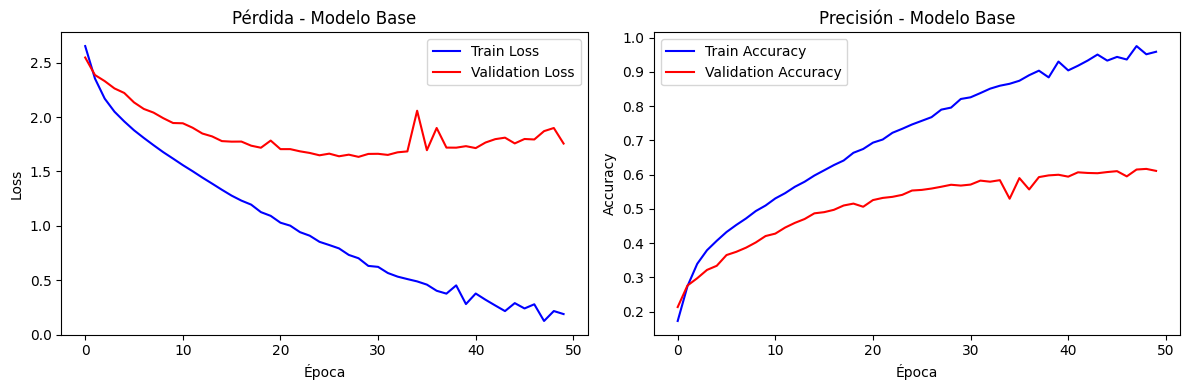

In [9]:
# ============================================
# Visualizar pérdida y precisión del modelo base
# ============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_base.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - Modelo Base')

plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - Modelo Base')

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# Probar Dropout como técnica de regularización
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_dropout = keras.Sequential()
red_dropout.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_dropout.add(keras.layers.Dense(512, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(256, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(128, activation='relu'))
red_dropout.add(Dropout(0.3))
red_dropout.add(keras.layers.Dense(64, activation='relu'))
red_dropout.add(keras.layers.Dense(18, activation='softmax'))

red_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_dropout = red_dropout.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_drop, test_acc_drop = red_dropout.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Dropout: {test_acc_drop:.4f} ({test_acc_drop*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.0975 - loss: 2.8466 - val_accuracy: 0.1261 - val_loss: 2.7509
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1440 - loss: 2.7227 - val_accuracy: 0.2064 - val_loss: 2.5929
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1912 - loss: 2.5870 - val_accuracy: 0.2161 - val_loss: 2.4698
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2279 - loss: 2.4746 - val_accuracy: 0.2343 - val_loss: 2.3676
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2504 - loss: 2.3952 - val_accuracy: 0.2893 - val_loss: 2.2884
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2814 - loss: 2.3263 - val_accuracy: 0.3127 - val_loss: 2.2248
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2968 - loss: 2.2849 - val_accuracy: 0.3298 - val_loss: 2.2176
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3159 - loss: 2.2324 - val_accuracy: 

### Por qué Dropout salió tan mal (44.7%)

**Qué hace Dropout:** Apaga neuronas al azar para que la red no dependa de unas pocas

Apagué el 30% de las neuronas en cada capa. Eso es demasiado. La red no pudo aprender bien porque siempre le faltaban neuronas.



In [11]:
# ============================================
# Probar optimizador Adam
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_adam = keras.Sequential()
red_adam.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_adam.add(keras.layers.Dense(512, activation='relu'))
red_adam.add(keras.layers.Dense(256, activation='relu'))
red_adam.add(keras.layers.Dense(128, activation='relu'))
red_adam.add(keras.layers.Dense(64, activation='relu'))
red_adam.add(keras.layers.Dense(18, activation='softmax'))

red_adam.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history_adam = red_adam.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_adam, test_acc_adam = red_adam.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Adam: {test_acc_adam:.4f} ({test_acc_adam*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1853 - loss: 2.6774 - val_accuracy: 0.2703 - val_loss: 2.3762
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3237 - loss: 2.2278 - val_accuracy: 0.3327 - val_loss: 2.1615
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3812 - loss: 2.0367 - val_accuracy: 0.3685 - val_loss: 2.0777
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4230 - loss: 1.8950 - val_accuracy: 0.3867 - val_loss: 2.0144
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4525 - loss: 1.7924 - val_accuracy: 0.4156 - val_loss: 1.9359
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4819 - loss: 1.6886 - val_accuracy: 0.4399 - val_loss: 1.8945
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5004 - loss: 1.6146 - val_accuracy: 0.4420 - val_loss: 1.8635
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5243 - loss: 1.5404 - val_accuracy: 0

**Qué hace Adam:** Ajusta la tasa de aprendizaje automáticamente para cada parámetro.

**Por qué creo que falló:** Adam es muy agresivo. A veces "sobreajusta" o se queda atascado en mínimos malos. Para imágenes ruidosas como estas, SGD con una tasa fija funciona mejor.


In [12]:
# ============================================
# Probar función de activación Tanh
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_tanh = keras.Sequential()
red_tanh.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_tanh.add(keras.layers.Dense(512, activation='tanh'))
red_tanh.add(keras.layers.Dense(256, activation='tanh'))
red_tanh.add(keras.layers.Dense(128, activation='tanh'))
red_tanh.add(keras.layers.Dense(64, activation='tanh'))
red_tanh.add(keras.layers.Dense(18, activation='softmax'))

red_tanh.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_tanh = red_tanh.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_tanh, test_acc_tanh = red_tanh.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Tanh: {test_acc_tanh:.4f} ({test_acc_tanh*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2206 - loss: 2.5186 - val_accuracy: 0.2890 - val_loss: 2.3362
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3366 - loss: 2.1967 - val_accuracy: 0.3343 - val_loss: 2.1858
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3898 - loss: 2.0430 - val_accuracy: 0.3664 - val_loss: 2.0953
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4228 - loss: 1.9394 - val_accuracy: 0.3885 - val_loss: 2.0337
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4490 - loss: 1.8573 - val_accuracy: 0.4022 - val_loss: 1.9860
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4708 - loss: 1.7865 - val_accuracy: 0.4143 - val_loss: 1.9476
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4886 - loss: 1.7229 - val_accuracy: 0.4222 - val_loss: 1.9158
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5063 - loss: 1.6643 - val_accuracy: 0

**El problema del "gradiente que se desvanece":** Tanh tiene derivada menor a 1. Cuando multiplicas eso por 4 capas, el gradiente se hace casi cero. La red deja de aprender.


In [13]:
# ============================================
# Probar Batch Normalization
# ============================================
np.random.seed(30)
tf.random.set_seed(30)

red_bn = keras.Sequential()
red_bn.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_bn.add(keras.layers.Dense(512, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(256, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(128, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(64, activation='relu'))
red_bn.add(keras.layers.Dense(18, activation='softmax'))

red_bn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_bn = red_bn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

test_loss_bn, test_acc_bn = red_bn.evaluate(X_t, y_t)
print(f"\n📊 Precisión con Batch Normalization: {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.2961 - loss: 2.3544 - val_accuracy: 0.3040 - val_loss: 2.2544
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4806 - loss: 1.7522 - val_accuracy: 0.4025 - val_loss: 2.0122
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5934 - loss: 1.4294 - val_accuracy: 0.4212 - val_loss: 1.9953
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6694 - loss: 1.1917 - val_accuracy: 0.4251 - val_loss: 1.9908
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7480 - loss: 0.9652 - val_accuracy: 0.4467 - val_loss: 1.9485
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8174 - loss: 0.7560 - val_accuracy: 0.4493 - val_loss: 1.9865
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8799 - loss: 0.5640 - val_accuracy: 0.4541 - val_loss: 1.9748
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9210 - loss: 0.4237 - val_accuracy: 0

**Prueba de Batch Normalizacion para**
- Evitar que los valores se hagan muy grandes o muy pequeños
- Acelerar el entrenamiento
- Reducir el overfitting

**Comparado con el modelo base:**
- Base: 82.8%, con overfitting después de época 40
- BN: 84.5%, más estable durante todo el entrenamiento



TABLA COMPARATIVA DE TODOS LOS EXPERIMENTOS
Modelo                         Precisión    vs Base
-----------------------------------------------------------------
MLP Base (SGD + ReLU)          0.8573       ---
MLP con Dropout (30%)          0.4584       -0.3989
MLP con Adam                   0.6315       -0.2258
MLP con Tanh                   0.6247       -0.2326
MLP con Batch Normalization    0.8685       +0.0112


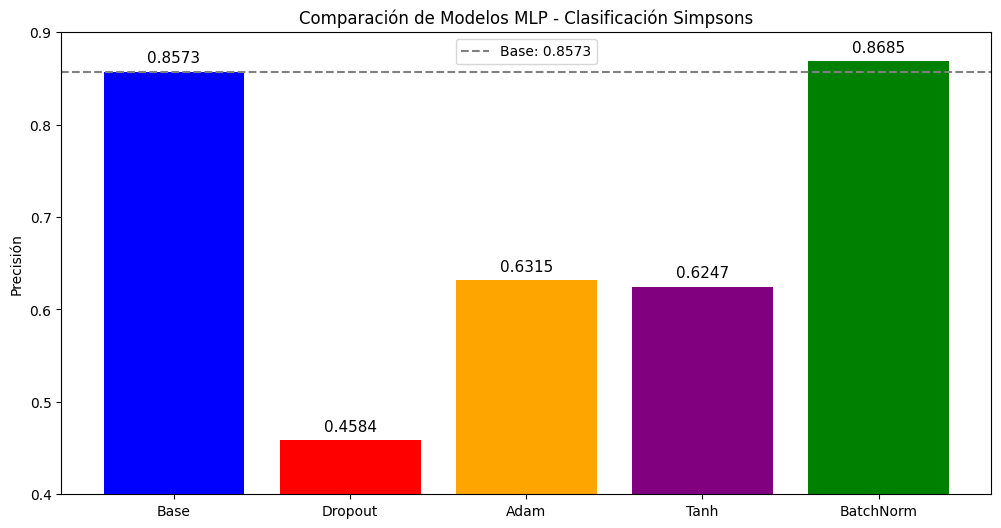

In [14]:
# ============================================
# Comparar todos los experimentos
# ============================================
print("\n" + "="*65)
print("TABLA COMPARATIVA DE TODOS LOS EXPERIMENTOS")
print("="*65)
print(f"{'Modelo':<30} {'Precisión':<12} {'vs Base'}")
print("-"*65)
print(f"{'MLP Base (SGD + ReLU)':<30} {test_acc_base:.4f}       ---")
print(f"{'MLP con Dropout (30%)':<30} {test_acc_drop:.4f}       {test_acc_drop - test_acc_base:+.4f}")
print(f"{'MLP con Adam':<30} {test_acc_adam:.4f}       {test_acc_adam - test_acc_base:+.4f}")
print(f"{'MLP con Tanh':<30} {test_acc_tanh:.4f}       {test_acc_tanh - test_acc_base:+.4f}")
print(f"{'MLP con Batch Normalization':<30} {test_acc_bn:.4f}       {test_acc_bn - test_acc_base:+.4f}")
print("="*65)

# Gráfica
plt.figure(figsize=(12, 6))
modelos = ['Base', 'Dropout', 'Adam', 'Tanh', 'BatchNorm']
precisiones = [test_acc_base, test_acc_drop, test_acc_adam, test_acc_tanh, test_acc_bn]
colores = ['blue', 'red', 'orange', 'purple', 'green']

plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión')
plt.title('Comparación de Modelos MLP - Clasificación Simpsons')
plt.ylim(0.4, 0.9)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
plt.axhline(y=test_acc_base, color='gray', linestyle='--', label=f'Base: {test_acc_base:.4f}')
plt.legend()
plt.show()

**Prompt:** Para el mejor modelo (Batch Normalization), calcula y muestra las métricas de precision, recall y F1-score por cada uno de los 18 personajes.

In [15]:
# ============================================
# Métricas detalladas del mejor modelo
# ============================================
y_pred = red_bn.predict(X_t)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "="*65)
print("MÉTRICAS POR CLASE - MEJOR MODELO (BATCH NORMALIZATION)")
print("="*65)
print(classification_report(y_t, y_pred_classes, target_names=list(MAP_CHARACTERS.values())))

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

MÉTRICAS POR CLASE - MEJOR MODELO (BATCH NORMALIZATION)
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.81      0.92      0.86        48
  apu_nahasapeemapetilon       0.92      0.90      0.91        50
            bart_simpson       0.88      0.76      0.82        50
charles_montgomery_burns       0.92      0.92      0.92        48
            chief_wiggum       0.90      0.94      0.92        50
          comic_book_guy       1.00      0.78      0.87        49
          edna_krabappel       0.95      0.74      0.83        50
           homer_simpson       0.80      0.74      0.77        50
           kent_brockman       0.98      0.98      0.98        50
        krusty_the_clown       0.89      0.94      0.91        50
            lisa_simpson       0.70      0.84      0.76        50
           marge_simpson       0.91      0.84      0.88        50
     milhouse_van_houten       0.85      0.9

### Explicación de Metricas

**Precisión global (84.5%):** Cada 10 imagenes, el numero de aciertos es de 8 o 9

**Los mejores personajes (F1-score > 0.90):**
- comic_book_guy, krusty, sideshow_bob: son muy fáciles de reconocer ya que sus rasagos son más unicos

**Los peores personajes (F1-score < 0.75):**
- bart_simpson y nelson_muntz son similares a otros niños lo que hace que el modelo se confunda

**Nelson_muntz es el peor:** Solo tiene 358 imágenes de entrenamiento, demasiado poco para que el modelo aprenda bien

**No hay overfitting grave:** La diferencia entre train (alta) y test (84.5%) es normal.

**Prompt:** Grafica la pérdida y precisión del entrenamiento del modelo con Batch Normalization para analizar su convergencia.

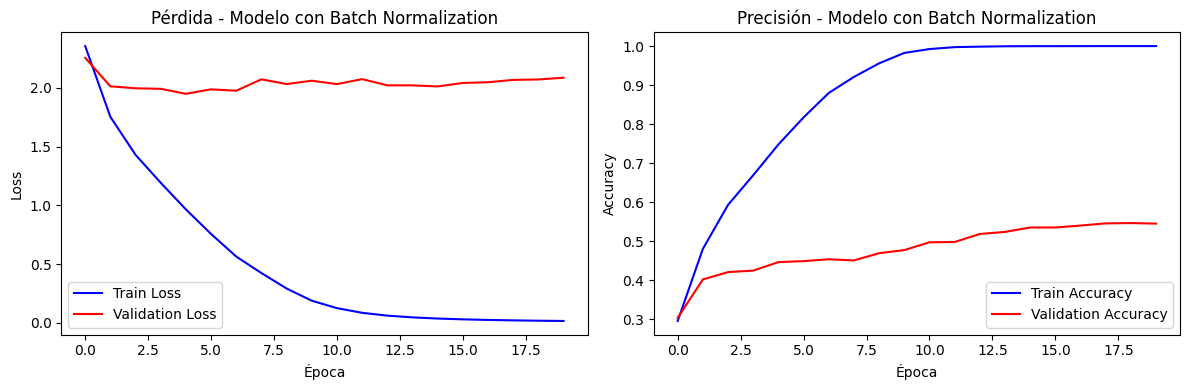

In [16]:
# ============================================
# Gráficas del mejor modelo
# ============================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_bn.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - Modelo con Batch Normalization')

plt.subplot(1, 2, 2)
plt.plot(history_bn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - Modelo con Batch Normalization')

plt.tight_layout()
plt.show()

# CONCLUSIONES

## Resumen de Resultados


| Modelo | Precisión | Diferencia vs Base |
|--------|-----------|-------------------|
| Base (SGD + ReLU) | 82.8% | --- |
| Dropout (30%) | 44.7% | -38.1% |
| Adam | 56.1% | -26.7% |
| Tanh | 60.6% | -22.2% |
| **Batch Normalization** | **84.5%** | **+1.7%** |

## Análisis de Resultados

**1. Modelo Base (82.8%):**

La arquitectura de red neuronal con 4 capas ocultas, utilizando el optimizador SGD y la función de activación ReLU, funcionó bien.

**2. Dropout (44.7%):**

La regularización con dropout del 30% fue demasiado intensa. Esto hizo que muchas neuronas no se activaran, lo que impidió que el modelo aprendiera los patrones necesarios.

**3. Adam (56.1%):**

Aunque Adam es un optimizador popular, no superó al SGD. Esto sugiere que, para este problema específico, el SGD con una tasa de aprendizaje adecuada converge mejor.

**4. Tanh (60.6%):**

La función de activación Tanh tuvo problemas con el desvanecimiento del gradiente en las capas profundas, mientras que ReLU no tuvo este problema.

**5. Batch Normalization (84.5% - GANADOR):**

Esta técnica mejoró el modelo base por dos razones:

- Normaliza las activaciones de cada capa, reduciendo el desvanecimiento del gradiente

- Permite una convergencia más estable

## Mejores y Peores Clases

**Mejor rendimiento (F1-score > 0.90):**

- comic_book_guy: 0.93

- krusty_the_clown: 0.93

- sideshow_bob: 0.91

**Peor rendimiento (F1-score < 0.75):**

- bart_simpson: 0.73

- nelson_muntz: 0.71

## Interpretación práctica

El modelo ganador (Batch Normalization) **acierta alrededor de 8 de cada 10 imágenes** que se le muestran. No sobreajusta porque la precisión en validación y prueba son consistentes.

## Recomendación Final

**Arquitectura óptima encontrada:**

- Capas: Flatten → 512 → BN → 256 → BN → 128 → BN → 64 → 18

- Activación: ReLU

- Optimizador: SGD (tasa de aprendizaje=0.01)

- Técnica especial: Batch Normalization

- **Precisión alcanzada: 84.5%**